*  DSC 540-T302 Data Preparation
*  Term Project: Milestone 5
*  Peter Lozano

# Import libraries

In [1]:
import sqlite3 # For database connection
import pandas as pd # For data manipulation
import plotly.express as px # For data visualization
import plotly.graph_objects as go # For more complex visualizations
from plotly.subplots import make_subplots # For visualizations subplots

The prior Milestone notebooks have been adjusted to write to a pickle file instead of a CSV file to preserve the data types and structure of the DataFrames. This is particularly important since each milestone has its own unique data retrieval and cleaning processes, and I want to ensure that the data is preserved accurately for this milestone.

# Validating that the data is being imported correctly from the .py files

## Flat File Data

In [2]:
flat_file_cleaned = pd.read_pickle("Lozano_P_Milestone_2_Data.pkl")
flat_file_cleaned

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
8,Payoneer,New York City,60,2025-12-08,0.06,Finance,https://www.calcalistech.com/ctechnews/article...,Post-IPO,<NA>,United States,2025-12-08
16,Hp,SF Bay Area,4000,2025-11-25,<NA>,Hardware,https://www.wsj.com/tech/hp-to-cut-up-to-10-of...,Post-IPO,<NA>,United States,2025-03-01
28,Synopsys,SF Bay Area,2000,2025-11-12,0.1,Other,https://www.reuters.com/business/world-at-work...,Post-IPO,<NA>,United States,2025-11-14
34,Hewlett Packard Enterprise,SF Bay Area,52,2025-11-05,<NA>,Hardware,https://www.sfchronicle.com/tech/article/layof...,Post-IPO,1400.0,United States,2025-11-07
39,Amazon,Seattle,14000,2025-10-27,0.01,Retail,https://www.cnbc.com/2025/10/28/amazon-layoffs...,Post-IPO,8100.0,United States,2025-10-28
...,...,...,...,...,...,...,...,...,...,...,...
4004,Eventbrite,SF Bay Area,500,2020-04-08,0.45,Consumer,https://layoffs.fyi/2020/04/13/eventbrite-laid...,Post-IPO,332.0,United States,2020-04-08
4027,Sage Therapeutics,Boston,340,2020-04-07,0.53,Healthcare,https://www.biopharmadive.com/news/sage-restr...,Post-IPO,438.0,United States,2020-04-08
4028,Redfin,Seattle,236,2020-04-07,0.07,Real Estate,https://www.geekwire.com/2020/redfin-lays-off-...,Post-IPO,319.0,United States,2020-04-07
4079,Mindbody,San Luis Obispo,700,2020-04-02,0.35,Fitness,https://www.sanluisobispo.com/news/business/ar...,Post-IPO,114.0,United States,2020-04-02


I want to change the column name from "company" to "Company" to match the wiki table as well, which will also help with the join later on.

In [3]:
flat_file_cleaned.rename(columns={'company': 'Company'}, inplace=True)

## Web Scraped Data

In [4]:
df_wiki = pd.read_pickle("Lozano_P_Milestone_3_Data.pkl")
df_wiki

,Ticker,Company,Industry,GICS Sub-Industry,Headquarters Location,Date added,City,State
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,Saint Paul,Minnesota
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,Milwaukee,Wisconsin
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,North Chicago,Illinois
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,North Chicago,Illinois
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,Dublin,Ireland
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,White Plains,New York
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,Louisville,Kentucky
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,Lincolnshire,Illinois
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,Warsaw,Indiana


## API Data

As shown below, I don't just have **Google's** stock data, nor is it limited to the most recent date. I have historical stock data for all the tickers in our wiki table, which is exactly what I need for our SQL merging in this milestone.

In [5]:
df_api = pd.read_pickle("Lozano_P_Milestone_4_Data.pkl")
df_api

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Change_Pct
782279,2019-11-11,ZTS,117.290,118.150,116.2900,117.03,2035190,-0.221673
467040,2019-11-11,MPC,65.440,66.450,65.0600,65.71,2249258,0.412592
273706,2019-11-11,EPAM,187.750,196.730,187.2300,194.28,308304,3.478029
26654,2019-11-11,ALLE,115.050,116.350,115.0500,115.66,388062,0.530204
468624,2019-11-11,MAR,132.250,132.430,130.8300,131.75,1282675,-0.378072
...,...,...,...,...,...,...,...,...
718574,2026-03-03,UPS,112.515,113.590,110.8700,113.24,4837777,0.644359
213787,2026-03-03,CSX,42.810,42.925,42.0300,42.66,12362889,-0.350385
536737,2026-03-03,NRG,162.310,164.040,158.0000,162.07,11469215,-0.147865
215371,2026-03-03,CMI,556.000,566.510,552.2200,560.16,1081379,0.748201


## Final Cleaning

Now, I have to apply some more cleaning to the company names in the flat file data that contains the layoff data for tech companies. Since it doesn't supply me with the tickers, I have to make sure that the company name is clean and matches the company name in the wiki table, which will allow for a successful join later on when creating the SQL database. I will do this by creating an alias map that maps the company names in the flat file to the company names in the wiki table, and then applying that alias map to the company names in the flat file. 

My objective is to see if layoffs are impacting the stock prices that are influenced by the stock holders making decisions of the company and not influenced by other factors. To do this, I will ensure that I use ticker **classes** that have voting rights since other ticker classes are typically used for raising capital, acquisitions, or employee compensation. I check this by inspecting the results using the `head()` function to check the first few rows of the DataFrame after applying the alias map.

Lastly, since there are a lot of companies that are not part of the **S&P 500**, I will only include the companies that are part of the **S&P 500** in the alias map, which will allow for a successful join later on when creating the SQL database.

In [6]:
# Clean function of company names for matching
def clean_company_name(name):
    name = str(name).lower().strip()
    name = name.replace('.', '')
    name = name.replace(',', '')
    name = name.replace(' inc', '')
    name = name.replace(' group', '')
    return name.strip()

# Company alias map (raw -> cleaned)
raw_alias_map = {
    # Using stock ticker with voting class where applicable
    'Google': 'Alphabet (Class A)',
    'Meta': 'Meta Platforms',
    'Tesla Motors': 'Tesla',
    'Salesforce': 'Salesforce.com',
    'Booking.com': 'Booking Holdings',
    'Applied Material': 'Applied Materials'
}

# Clean the alias map keys and values
alias_map = {clean_company_name(k): clean_company_name(v) for k, v in raw_alias_map.items()}

# Clean company names on both datasets
flat_file_cleaned['clean_name'] = flat_file_cleaned['Company'].apply(clean_company_name).replace(alias_map)

# alias_map is not needed for df_wiki since it contains the official names
df_wiki['clean_name'] = df_wiki['Company'].apply(clean_company_name)

# Build a unique wiki lookup (choose first if duplicates)
wiki_lookup = (
    df_wiki
    .sort_values('Company')
    .drop_duplicates(subset=['clean_name'], keep='first')
    .set_index('clean_name')['Ticker']
)

# Assign tickers by key to guarantee alignment
flat_file_cleaned['Ticker'] = flat_file_cleaned['clean_name'].map(wiki_lookup)

# Check results of matching/unmatched companies
print("Matched tickers:", flat_file_cleaned['Ticker'].nunique(dropna=True))
print("Unmatched count:", len(flat_file_cleaned.loc[flat_file_cleaned['Ticker'].isna(), 'Company'].unique()))
print("Unmatched examples:", flat_file_cleaned.loc[flat_file_cleaned['Ticker'].isna(), 'Company'].unique())

Matched tickers: 44
Unmatched count: 231
Unmatched examples: <StringArray>
[         'Payoneer',             'Chegg',            'Rivian',
        'Smartsheet',      'Ziprecruiter',        'Salesforce',
            'Oracle',            'Micron',           'Kaltura',
          'Nextdoor',
 ...
          'Zymergen',              'Yelp',    'Funding Circle',
   'Rubicon Project',         'Livetiles',            'Casper',
          'Cargurus',              'Domo', 'Sage Therapeutics',
             'Maven']
Length: 231, dtype: string


What I found interesting is that there are some companies in the flat file that are not in the wiki table, and some companies in the wiki table that are not in the flat file. This is because the flat file contains layoff data for tech companies, and not all tech companies are part of the S&P 500 but could be part of S&P 100. Additionally, some companies in the wiki table may not have had any layoffs during the time period covered by the flat file or may not be tech companies, which is why they are not included in the flat file. This leaves me with a smaller subset of companies to work with (i.e., **44** companies).

I will have to ensure that my final note includes this detail of my final report containing only **Tech Companies** that are part of the **S&P 500** that **have layoffs between 2020 through 2026**, to ensure that I am accurately representing the data and the scope of my analysis.

# Create and Connect to SQLite Database

In [7]:
# Create Database & Load Data
conn = sqlite3.connect('my_layoff_data.db')
cursor = conn.cursor()

## Load the 3 cleaned dataframes into the database as individual tables 

To ensure I don't duplicate data if I run this cell multiple times, I use 'if_exists="replace"' which will overwrite the existing table with the new data.

In [8]:
# Load our 3 cleaned dataframes into the database as individual tables
flat_file_cleaned.to_sql('layoffs', conn, if_exists='replace', index=False)
df_wiki.to_sql('sp500', conn, if_exists='replace', index=False)
df_api.to_sql('stock_data', conn, if_exists='replace', index=False)

print("Data successfully loaded into SQLite database.")

Data successfully loaded into SQLite database.


## SQL Merging

Now that all the data is in the database, we can use SQL to merge it together. This is where we can do more complex joins and aggregations if needed.

In [9]:
# This query uses a LEFT JOIN to keep all stock data records even if we are missing layoff data for that specific day.
query = """
SELECT 
    s.Date,
    w.Company,
    s.Ticker,
    l.Date as Layoff_Date,
    l.total_laid_off,
    w.Industry,
    w.State as HQ_State,
    s.Close as Stock_Price,
    s.Open as Stock_Open,
    s.High as Stock_High,
    s.Low as Stock_Low,
    s.Daily_Change_Pct,
    s.Volume as Stock_Volume
FROM stock_data s
LEFT JOIN sp500 w ON s.Ticker = w.Ticker
LEFT JOIN layoffs l ON s.Date = l.Date AND s.Ticker = l.Ticker
"""

## Execute the SQL query to merge the data and close the database connection

In [10]:
# Execute the query and store the result in a new "Master" DataFrame
df_merged = pd.read_sql_query(query, conn)

# Close the connection strictly for good practice
conn.close()

# Verify the Merged Data
print("Merged Dataset Head:")
print(df_merged.head())
print(f"Total Rows in Merged Data: {len(df_merged)}")

Merged Dataset Head:
                  Date                 Company Ticker Layoff_Date  \
0  2019-11-11 00:00:00                  Zoetis    ZTS        None   
1  2019-11-11 00:00:00      Marathon Petroleum    MPC        None   
2  2019-11-11 00:00:00            EPAM Systems   EPAM        None   
3  2019-11-11 00:00:00                Allegion   ALLE        None   
4  2019-11-11 00:00:00  Marriott International    MAR        None   

   total_laid_off                Industry      HQ_State  Stock_Price  \
0             NaN             Health Care    New Jersey       117.03   
1             NaN                  Energy          Ohio        65.71   
2             NaN  Information Technology  Pennsylvania       194.28   
3             NaN             Industrials       Ireland       115.66   
4             NaN  Consumer Discretionary      Maryland       131.75   

   Stock_Open  Stock_High  Stock_Low  Daily_Change_Pct  Stock_Volume  
0      117.29      118.15     116.29         -0.221673      

# Visualization

First I need to prep my data so that I can graph it appropriately. For example, I will need to reapply the date datatype to my date fields if I want to use a line graph.

The metadata is lost due to the data source now being from the SQL query instead of the original DataFrame.

In [11]:
# --- VISUALIZATION PREP ---
# Ensure dates are datetime objects and handle missing values
df_merged['Layoff_Date'] = pd.to_datetime(df_merged['Layoff_Date'])
df_merged['Date'] = pd.to_datetime(df_merged['Date'])

Also, I will be using a **moving average** to use as a baseline against the event-day stock volume. A moving average is a commonly used technical indicator in stock analysis that helps to identify trends by averaging the stock volume over a specific period of time. This will help to understand how the stock volume on the layoff event day compares to the average stock volume in the days leading up to the event, which can provide insights into how the market is reacting to the news of the layoffs.

[Investopedia: Moving Average](https://www.investopedia.com/terms/m/movingaverage.asp)

## Importance of Stock Volume Data

The importance of the stock volume data is that it can provide insights into the level of interest and activity in a particular stock. High trading volume can indicate strong investor interest and can be a sign of a potential price movement, while low trading volume can indicate a lack of interest and may suggest that the stock is not as actively traded. By analyzing the stock volume data alongside the stock price data, I can gain a better understanding of the overall market sentiment and the potential impact of the layoffs. For example, if there is a significant increase in trading volume around the time of a layoff announcement, it could indicate that investors are reacting to the news and may be selling off their shares, which could lead to a decrease in stock price. Conversely, if there is a significant decrease in trading volume around the time of a layoff announcement, it could indicate that investors are not reacting to the news and may be holding onto their shares, which could lead to a stable or even increase in stock price.

To do so, I will need to split up my data into three separate DataFrames, one for the stock price data, one for the stock volume data, and one for the layoff data. This will allow me to create a subplot that contains all three visualizations in one figure.

## Data Preparation for Visualization

In [12]:
# Stock Dataset
stock_daily = (
    df_merged[['Company', 'Date', 'Stock_Volume']]
    .dropna(subset=['Company', 'Date', 'Stock_Volume'])
    .drop_duplicates(subset=['Company', 'Date'])
    .sort_values(['Company', 'Date'])
    .copy()
)

# Layoff dataset
layoff_events = (
    df_merged[['Company', 'Layoff_Date', 'total_laid_off']]
    .dropna(subset=['Company', 'Layoff_Date', 'total_laid_off'])
    .drop_duplicates(subset=['Company', 'Layoff_Date'])
    .sort_values(['Company', 'Layoff_Date'])
    .copy()
)

To create the **moving average** for the stock volume data, I will need to follow specific parameters to avoid distortion due to the potential impact of layoffs on the stock volume. To avoid this, I will remove roughly a week before and a week after the layoff events from the stock volume data when calculating the moving average. This will help to ensure that the moving average is not skewed by any sudden spikes or drops in trading volume that may occur around the time of the layoffs, which could be caused by investors reacting to the news.

Other than that, I will use **120-day moving average** for the stock volume data, which is right in the middle of what short-term and long-term moving averages typically are. A short-term moving average is typically around 50 days, while a long-term moving average is typically around 200 days. By using a 120-day moving average, I can capture the medium-term trends in the stock volume data while still smoothing out some of the noise in the data.

With the oultined parameters, I will calculate the **moving average** for the stock volume data by grouping by `Company` with layoff data and dynamically extracting the dates of the layoff events for each company, and then applying a rolling mean to the stock volume data while excluding the dates around the layoff events. This will allow me to create a more accurate moving average that reflects the underlying trends in the stock volume data without being distorted by the potential impact of the layoffs.

In [13]:
results = []

for company, ev_grp in layoff_events.groupby('Company'):
    # Get stock data for this company
    comp_stock = stock_daily.loc[stock_daily['Company'] == company, ['Date', 'Stock_Volume']].copy()
    # Get all layoff dates for this company
    lay_dates = ev_grp['Layoff_Date'].sort_values().to_list()

    # Loop through each layoff date
    for lay_date in lay_dates:
        # Define the 120-day pre-layoff window
        start = lay_date - pd.Timedelta(days=120)
        # Define the end of the pre-layoff window
        end = lay_date - pd.Timedelta(days=1)

        # Extract the stock volume data for this window
        win = comp_stock[(comp_stock['Date'] >= start) & (comp_stock['Date'] <= end)].copy()

        # If any, exclude +/- 7 days around all layoff events for this company
        if not win.empty:
            blackout = pd.Series(False, index=win.index)
            for d in lay_dates:
                # Mark the +/- 7 day window around each layoff date as True in the blackout series
                blackout |= win['Date'].between(d - pd.Timedelta(days=7), d + pd.Timedelta(days=7))
            # Exclude those blackout days from the window
            win = win.loc[~blackout]

        # Calculate the average stock volume in the remaining pre-layoff window
        avg_120d_pre = win['Stock_Volume'].mean() if not win.empty else pd.NA

        # Store the results in a list of dictionaries for later DataFrame creation
        results.append({
            'Company': company,
            'Layoff_Date': lay_date,
            'Avg_120D_PreLayoff_Volume': avg_120d_pre,
            'Pre_Window_Trading_Days_Used': int(len(win))
        })

prelayoff_vol = pd.DataFrame(results)

# Merge to layoff-event rows in df_merged
df_merged = df_merged.merge(
    prelayoff_vol,
    on=['Company', 'Layoff_Date'],
    how='left'
)

# Event-day volume vs pre-layoff baseline (%)
df_merged['Volume_vs_120D_PreLayoff_Pct'] = (
    (df_merged['Stock_Volume'] / df_merged['Avg_120D_PreLayoff_Volume']) - 1
) * 100


viz_df = df_merged.dropna(subset=['total_laid_off'])

Now that I have enriched my dataset with a moving average (i.e., `Volume_vs_120D_PreLayoff_Pct`) for the stock volume data, I can begin with my visualization.

## Visualization 1: Who had the most layoffs within our time period (i.e., 2020 through Q1-2026)?

In [14]:
# --- VISUALIZATION 1: Single Source (Layoffs) ---
# Goal: Show who had the biggest cuts.
top_companies = viz_df.groupby('Company')['total_laid_off'].sum().sort_values(ascending=False).head(10).reset_index()

fig1 = px.bar(top_companies, 
              x='total_laid_off', 
              y='Company', 
              orientation='h',
              title='Visualization 1: Top 10 Companies by Total Layoffs (2020-Present)',
              labels={'total_laid_off': 'Total Employees Laid Off'},
              color='total_laid_off',
              color_continuous_scale='Reds')
fig1.update_layout(yaxis={'categoryorder':'total ascending'})
fig1.show()

I chose the color palette of **Reds** for this visualization because it is commonly associated with negative events or outcomes, which is fitting for a visualization that is focused on layoffs. The use of a red color palette can help to visually emphasize the severity of the layoffs and draw attention to the companies that have been most impacted. Additionally, using a consistent color palette across all aspects of the visualization is easier to read due to accessibility reasons.

Also, this visual is simply to show where the "heavy hitters" are in terms of layoffs and not necessarily to show a comparison of the companies to each other since each company are different sizes and have different numbers of employees.

This visualization is simply to show what companies to mostly focus on since their layoff numbers are significantly higher than the rest of the companies in my dataset.

## Visualization 2: Monthly Timeline Trend of Layoffs

In [15]:
# --- VISUALIZATION 2: Single Source (Layoffs) ---
# Goal: Show the timeline trends (Monthly Aggregation)
monthly_layoffs = viz_df.set_index('Layoff_Date').resample('ME')['total_laid_off'].sum().reset_index()

fig2 = px.line(monthly_layoffs, 
               x='Layoff_Date', 
               y='total_laid_off', 
               title='Visualization 2: Timeline of Layoffs (Monthly Trends)',
               labels={'Layoff_Date': 'Date', 'total_laid_off': 'Total Layoffs'},
               markers=True)
fig2.show()

This visual is to show the trend of layoffs over time, which can help to identify any patterns or spikes in layoffs that may have occurred during the time period covered by the dataset. By plotting the number of layoffs on a monthly timeline, I can see if there are any specific months or quarters where layoffs were more prevalent, which could be indicative of broader economic trends or industry-specific challenges.

## Visualization 3: Impact of Layoffs by Industry

In [16]:
# --- VISUALIZATION 3: Multi-Source (Layoffs + Wiki) ---
# Goal: Analyze impact by industry (Sector).
industry_impact = viz_df.groupby('Industry')['total_laid_off'].sum().sort_values(ascending=False).reset_index()

fig3 = px.bar(industry_impact, 
              x='Industry', 
              y='total_laid_off', 
              title='Visualization 3: Total Layoffs by GICS Sector (Merged Data)',
              color='Industry')
fig3.show()

Although the scope of this project is based on **Tech Companies** that are part of the **S&P 500**, I can still categorize the companies by their respective industries (e.g., Software, Hardware, Health Care, etc.) and analyze the impact of layoffs on stock prices within each industry. This visualization can help to identify if certain industries were more heavily impacted by layoffs and if there are any industry-specific trends in stock price reactions to layoffs.

## Visualization 4: Top 10 Average Stock Volume Change By Company Compared to 120-Day Moving Average

In [17]:
# --- VISUALIZATION 4: Volume Change Over Time by Company ---
# Goal: Show monthly average volume change (%) over time for the top 10 companies by average stock volume.

# Keep only relevant columns
vol_df = df_merged[[
    'Company', 
    'Date', 
    'Stock_Volume',
    'Daily_Change_Pct',
    'Volume_vs_120D_PreLayoff_Pct',
    'total_laid_off'
]].copy()

# Ensure data is sorted to calculate averages correctly
vol_df = vol_df.sort_values(['Company', 'Date'])
vol_df['Date'] = pd.to_datetime(vol_df['Date'])

# Monthly average volume per company
monthly_vol = (
    vol_df.set_index('Date')
    .groupby('Company')
    # Using Month End frequency to capture monthly activity of layoffs
    .resample('ME').agg({
        'Stock_Volume': 'mean',
        'Daily_Change_Pct': 'mean',
        'Volume_vs_120D_PreLayoff_Pct': 'mean',
        'total_laid_off': 'mean'
    })
    .reset_index()
)

# Ensuring I only plot companies that have layoff data
companies_with_layoffs = (
    df_merged.loc[
        df_merged['Layoff_Date'].notna() & df_merged['total_laid_off'].notna(),
        'Company'
    ]
    .dropna()
    .unique()
)

# Top 10 by avg stock volume, restricted to companies with layoff data
top_companies = (
    monthly_vol[monthly_vol['Company'].isin(companies_with_layoffs)]
    .groupby('Company')['Stock_Volume']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_vol = monthly_vol[
    monthly_vol['Company'].isin(top_companies)
# Only keep rows where we have a valid percentage change to plot
].dropna(subset=['Volume_vs_120D_PreLayoff_Pct'])

# Parameters for the line plot
fig4 = px.line(
    plot_vol,
    x='Date',
    y='Volume_vs_120D_PreLayoff_Pct',
    color='Company',
    markers=True,
    title='Visualization 4: Top 10 Monthly Average Volume Change (%) Over Time by Company',
    labels={
        'Date': 'Date',
        'Volume_vs_120D_PreLayoff_Pct': 'Volume vs 120D Pre-Layoff (%)'
    },
    # Customize hover data for more informative tooltips
    hover_data={
        'Daily_Change_Pct': ':.2f',
        'Volume_vs_120D_PreLayoff_Pct': ':.2f',
        'Stock_Volume': ':.2f',
        'total_laid_off': ':.2f',
        'Date': '|%Y-%m-%d'
    }
)

fig4.add_hline(y=0, line_dash='dash', line_color='black')
fig4.show()

I find this visualization to be powerful in that it is easy to digest because any records below the dotted black line indicates that the layoff activity is having a negative impact on the stock volume. But, it is important to note that although the volume is showing a negative impact, it does not necessarily mean that the stock price is also showing a negative impact. As I indicated earlier, this is simply telling us the overall movement of the stock and how the investors are reacting to events for the time period. It may not even be influenced by the layoff event. Moreover, investors may not even react and hold for further clarification. However, by analyzing the stock volume data alongside the stock price data, I can gain a better understanding of the overall market sentiment and the potential impact of the layoffs on both volume and price.

For example, below you can see Amazon's stock volume change being the highest overall compared to the 120-day moving average, which indicates that there is a significant increase in trading volume around the time of the layoff announcement, which could indicate that investors are reacting to the news and may be selling off their shares, which could lead to a decrease in stock price. However, it is not showing a significant decrease in stock price as indicated by `Daily_Change_Pct` field, nor a significant increase either. There was a lot of volatility during October 2022. Since the price showed a slight increase, it provides me the overall sentiment which is neutral. Investors are not reacting to the news and may be holding onto their shares, which could lead to a stable or even an increase in stock price. This is why it is important to analyze both the stock volume and stock price data together to get a more complete picture of the market sentiment and the potential impact of the layoffs.

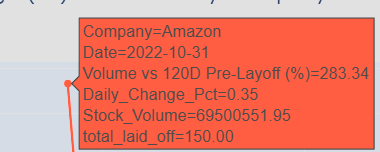

Conversly, I can see that Intel had a significant decrease in trading volume around July 2025 with a slighly lower stock price percentage. The only thing that is significantly different between this event and **Amazon's** event is the magnitude of the layoffs. **Amazon** had laid off **150** employees, while **Intel** had laid off **5,000** employees. This could indicate that investors are reacting more strongly to the news of the larger layoffs at **Intel** compared to the smaller layoffs at **Amazon**. But, it did **not** lead to a significant decrease in stock price for that month.

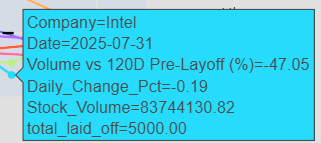

## Visualization 5: Correlation Between Layoff size and Stock Price reaction

In [18]:
# --- VISUALIZATION 5: Scatter Correlation (Layoffs + Stocks) ---
# Goal: Is there a correlation between layoff size and stock price reaction?
stock_viz = viz_df.dropna(subset=['Daily_Change_Pct'])

fig5 = px.scatter(stock_viz, 
                  x='total_laid_off', 
                  y='Daily_Change_Pct', 
                  color='Company',
                #   hover_data=['Company', 'Layoff_Date'],
                  title='Visualization 5: Market Reaction vs. Individual Layoff Events',
                  labels={
                    'Daily_Change_Pct': 'Stock Price Change % (Day of Layoff)',
                    'total_laid_off': 'Number of Employees Laid Off'},
                  hover_data={
                        # 'Layoff_Date': '|%Y-%m-%d',
                        'Company': True,
                        'total_laid_off': ':.2f',
                        'Daily_Change_Pct': ':.2f',
                        'Stock_Volume': ':.2f',
                        'Volume_vs_120D_PreLayoff_Pct': ':.2f'
                    }
)
fig5.add_hline(y=0, line_dash="dash", line_color="black")
fig5.show()

# Count how many companies had a negative stock price change on the layoff day vs positive change
negative_reactions = stock_viz[stock_viz['Daily_Change_Pct'] < 0]['Company'].count()
positive_reactions = stock_viz[stock_viz['Daily_Change_Pct'] >= 0]['Company'].count()

print(f"Number of company layoff events with negative stock price change on layoff day: {negative_reactions}")
print(f"Number of company layoff events with positive stock price change on layoff day: {positive_reactions}")

Number of company layoff events with negative stock price change on layoff day: 60
Number of company layoff events with positive stock price change on layoff day: 66


The prior visualization showed us the impact of layoffs on stock volume, but it is not easy to see the correlation between the size of the layoffs and the stock price reaction. To visualize this, I used a scatter plot to show the relationship between the number of layoffs and the percentage change in stock price on the layoff event day. To discern if stock price is impacted by layoff events, this visualization should show the majority of the data points below the dotted black line as this would indicate that the percentage change in stock price is negative on the layoff event day.

However, this visualization slightly leans towards a negative correlation between the size of the layoffs and the stock price reaction, but it is not a strong relationship. Since this is a small window, it is possible that the stock price reaction may not be fully captured in this visualization, and there may be other factors at play that are influencing the stock price reaction to the layoffs.

## Visualization 6: Stock Chart, Volume Box Plot, and Layoff Event Markers

In [ ]:
# --- VISUALIZATION 6: Stock-Style Overlay (Candlestick + Volume + Layoffs) ---

viz6_df = df_merged.dropna(subset=['Company', 'Date']).copy()
viz6_df['Date'] = pd.to_datetime(viz6_df['Date'])

# Filter to only companies with total_laid_off > 0
companies_with_layoffs = (
    viz6_df.groupby('Ticker')['total_laid_off']
    .sum()
    .loc[lambda x: x > 0]
    .index.tolist()
)

viz6_df = viz6_df[viz6_df['Ticker'].isin(companies_with_layoffs)].copy()

if viz6_df.empty:
    raise ValueError('No companies with layoff data available for Visualization 6.')

# Monthly candlestick data (Open, High, Low, Close)
viz6_df['YearMonth'] = viz6_df['Date'].dt.to_period('M')

candlestick_data = (
    viz6_df.dropna(subset=['Stock_Open', 'Stock_High', 'Stock_Low', 'Stock_Price'])
    .groupby(['Company', 'YearMonth'], as_index=False)
    .agg({
        'Stock_Open': 'first',
        'Stock_High': 'max',
        'Stock_Low': 'min',
        'Stock_Price': 'last',
        'Date': 'last'
    })
    .assign(Date=lambda d: d['YearMonth'].dt.to_timestamp())
    .sort_values(['Company', 'Date'])
)

# Monthly total layoffs per company
layoffs_monthly = (
    viz6_df.dropna(subset=['Layoff_Date', 'total_laid_off'])
    .assign(Layoff_Date=lambda d: pd.to_datetime(d['Layoff_Date']))
    .assign(YearMonth=lambda d: d['Layoff_Date'].dt.to_period('M'))
    .groupby(['Company', 'YearMonth'], as_index=False)['total_laid_off']
    .sum()
    .assign(Date=lambda d: d['YearMonth'].dt.to_timestamp())
)

# Volume box plot by month (daily distribution each month)
viz6_df['Month'] = viz6_df['Date'].dt.to_period('M').dt.to_timestamp()

companies = sorted(viz6_df['Company'].dropna().unique())
if not companies:
    raise ValueError('No companies available for Visualization 6.')

fig6 = go.Figure()

for idx, company in enumerate(companies):
    visible = idx == 0

    comp_candle = candlestick_data[candlestick_data['Company'] == company].copy()
    comp_vol = viz6_df[viz6_df['Company'] == company]
    comp_lay = layoffs_monthly[layoffs_monthly['Company'] == company]
    
    # Add candlestick trace with monthly data
    fig6.add_trace(
        go.Candlestick(
            x=comp_candle['Date'],
            open=comp_candle['Stock_Open'],
            high=comp_candle['Stock_High'],
            low=comp_candle['Stock_Low'],
            close=comp_candle['Stock_Price'],
            name=f"{company} Price (Monthly)",
            visible=visible,
            yaxis='y'
        )
    )

    fig6.add_trace(
        go.Box(
            x=comp_vol['Month'],
            y=comp_vol['Stock_Volume'],
            name=f"{company} Volume",
            visible=visible,
            yaxis='y2',
            opacity=0.45,
            boxmean=True
        )
    )

    fig6.add_trace(
        go.Scatter(
            x=comp_lay['Date'],
            y=comp_lay['total_laid_off'],
            mode='lines+markers',
            name=f"{company} Layoffs",
            visible=visible,
            yaxis='y3',
            line=dict(color='red', width=2)
        )
    )

# Dropdown to switch companies
buttons = []
for i, company in enumerate(companies):
    vis = [False] * (len(companies) * 3)
    start = i * 3
    vis[start:start + 3] = [True, True, True]
    buttons.append({
        'label': company,
        'method': 'update',
        'args': [{'visible': vis}, {'title': f"Visualization 6: Stock-Style Overlay ({company})"}]
    })

fig6.update_layout(
    title=f"Visualization 6: Stock-Style Overlay ({companies[0]})",
    xaxis_title='Date',
    yaxis=dict(title='Stock Price (Monthly Candlestick)', showgrid=True),
    yaxis2=dict(title='Stock Volume (Monthly Box Plot)', overlaying='y', side='right', showgrid=False),
    yaxis3=dict(overlaying='y', side='right', position=0.85, showgrid=False), # Monthly Layoffs
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    updatemenus=[{
        'buttons': buttons,
        'direction': 'down',
        'x': 0.0,
        'y': 1.15,
        'xanchor': 'left',
        'yanchor': 'top'
    }]
)

fig6.show()

I wanted to mimic the style of the typical "candle stick" stock price charts that are commonly used in financial analysis but, layered with the size of the layoffs on top. This visualization is combining both the size of the layoffs to the stock price and volume data to provide a more comprehensive view of the impact of layoffs on the stock performance of the companies in the dataset. By plotting each company one-by-one, it allows for a more detailed analysis of the sentiment of the market reaction prior to, on, and after the layoff events.

This visualization is plotted by using the start of the month as opposed to the end of the month for alignment purposes. It is a complex graph but it is very informative and provides a lot of insights into the impact of layoffs on stock performance. For example, earlier we determined that **Intel** had a significant amount of layoffs in our dataset. By plotting **Intel** and honing in on the month of the first significant layoff event in **August 2024** with **15,000** employees laid off, I can see that there was a lot of movement with a **negative** stock price movement within that same month because it closed lower than the open price at **$22.04**. However, it was followed by a **positive** stock price movement in the following month. Overall, the stock volume was low for the months leading up to its next layoff event in **February 2025** with a total of **58**. The stock price showed a **positive** movement between the layoff event in **August 2024** and the next layoff event in **February 2025** with a closing price at **$23.73**. The stock volume suggests that the significant spikes during these layoff events are not typical for **Intel** and that investors are reacting to the news of the layoffs, which could be leading to increased trading activity and volatility in the stock price. Another great callout is that the stock price was negatively impacted during significant layoff events like **Intel's** layoff event in **August 2024** with **15,000** employees laid off, but it was not significantly impacted during smaller layoff events like on **February 2025** with **58** impacted employees. This is further supported by the following layoff event in **April 2025** with **22,000** employees laid off showing a **negative** stock price movement with a closing price at **$20.10**.

During the span of 8 months, **Intel's** stock performance appears to be impacted by the layoff events by nearly **$2**! This is not putting into consideration other factors that may be influencing the stock price, like the industry trends, press releases, or broader economic conditions. However, statements publicized in press releases and news articles can have immediate impacts on stock price and volume, which can be observed in this visualization. It would be unlikely for a significant layoff event to occur during a press release but it could be possible during the same month. 

| August 2024 | February 2025 | April 2025 |
|---|:---|---:|
| 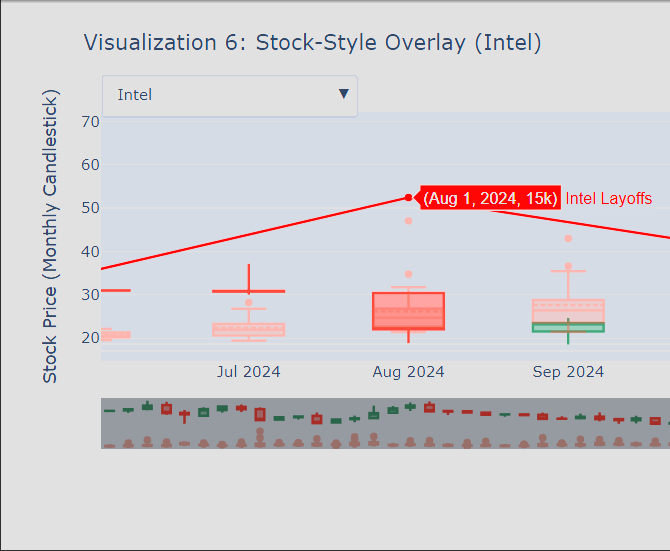 | 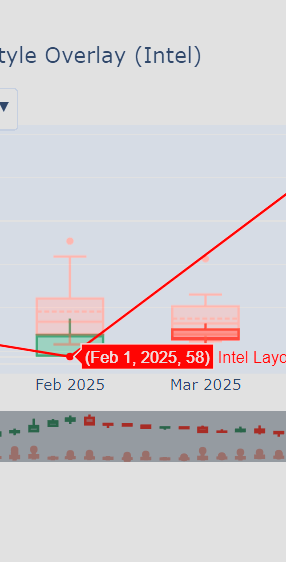 |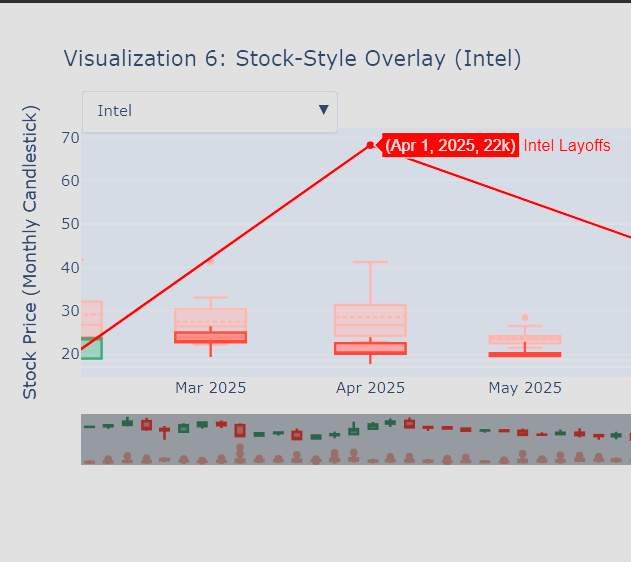 |

In [20]:
# --- FINAL REQUIREMENT: Print Human Readable Dataset ---
print("--- Final Merged Dataset (Sample) ---")
print(df_merged.head(10))

--- Final Merged Dataset (Sample) ---
        Date                    Company Ticker Layoff_Date  total_laid_off  \
0 2019-11-11                     Zoetis    ZTS         NaT             NaN   
1 2019-11-11         Marathon Petroleum    MPC         NaT             NaN   
2 2019-11-11               EPAM Systems   EPAM         NaT             NaN   
3 2019-11-11                   Allegion   ALLE         NaT             NaN   
4 2019-11-11     Marriott International    MAR         NaT             NaN   
5 2019-11-11              EOG Resources    EOG         NaT             NaN   
6 2019-11-11             Marsh McLennan   MRSH         NaT             NaN   
7 2019-11-11                    Entergy    ETR         NaT             NaN   
8 2019-11-11  Walt Disney Company (The)    DIS         NaT             NaN   
9 2019-11-11  Martin Marietta Materials    MLM         NaT             NaN   

                 Industry        HQ_State  Stock_Price  Stock_Open  \
0             Health Care      Ne

# Project Summary

In completing this data integration project, I successfully built a data pipeline that aggregates disparate data sources to analyze the relationship between corporate layoffs and stock market performance. The technical execution involved three distinct phases: cleaning a flat file of layoff records, scraping HTML data from Wikipedia to establish company metadata (Industry, Headquarters), and querying the Alpha Vantage Premium API to retrieve historical stock prices. The most significant challenge was combining the datasets due to inconsistencies in ticker symbol formats and/or missing tickers altogether, which required careful data normalization and cleaning to ensure a successful merge. I utilized Python’s sqlite3 library to act as a staging area, loading the three cleaned datasets as individual tables and performing a LEFT JOIN to create a unified master dataset. This approach allowed me to visualize not just the volume of layoffs, but their stock price performance and the immediate financial market reaction, revealing that while tech companies in the IT Sector faced the highest volume of cuts, the stock market reaction was highly variable and not uniformly negative.

## What changes were made to the data?

The primary changes involved standardization. Company names were normalized to Title Case to ensure string matching, converted to reflect parent company naming convention when applicable, and ticker symbols were sanitized. Critically, I filtered the stock data to the 2020–2026 window to align with the layoff events, discarding older historical data to reduce processing load. However, this also included an additional 120-day window for calculating the moving average, which was necessary for the visualizations.

## Are there any legal or regulatory guidelines for your data or project topic?

The project strictly adhered to the Alpha Vantage Terms of Service by utilizing a paid Premium key to access historical data legally, rather than scraping protected financial charts. This project is purely for academic analysis and not financial advice. With that said, it is to inform readers about the potential impact of layoffs on stock performance, but it should not be used as a basis for making investment decisions.

## What risks could be created based on the transformations done?

A major risk introduced by the transformation is that it is not abundantly clear that the stock tickers used to align to the layoff data was strictly for the voting rights class of stock, which is typically the most widely held class of stock and the one that is most commonly analyzed in financial markets. But other stock classes may have different reactions to the layoff events, and by not including them in the analysis, it could lead to a skewed understanding of the overall market reaction to the layoffs.

Another risk is that the analysis has strict parameters for the moving average calculation, which may exclude relevant data points and potentially skew the results. For example, by excluding a week before and a week after the layoff events, I may be missing out on important market reactions that occur in that time frame, which could lead to an incomplete understanding of the impact of layoffs on stock performance for a layoff event that follows. Additionally, the choice of a 120-day moving average may not capture shorter-term trends or longer-term trends effectively, which could also impact the insights drawn from the visualizations. These parameters were chosen to try to mitigate the impact of the layoffs on the stock volume data, but it is important to acknowledge that they may also introduce some bias into the analysis.

Another risk is that this analysis is applicable to all industries and not just tech companies, which could lead to a skewed analysis if the impact of layoffs on stock performance is different for tech companies compared to other industries. This could be mitigated by including a dataset that includes all industry layoff events but, I am limited to just tech companies for this project.

Lastly, the dataset is limited to the time period of 2020 through Q1-2026, which may include some unprecedented events such as the COVID-19 pandemic, which could have a significant impact on the stock performance of companies and may not be representative of typical market conditions. Additionally, some companies like Google had transformed their business model to make their shares more accessible to retail investors, which could overshadow any potential impact of layoffs on stock performance.

## Did you make any assumptions in cleaning/transforming the data?

I assumed that the "Layoff Date" in the CSV corresponded exactly to the market trading day. In reality, layoffs announced after 4:00 PM would affect the next day's stock price, a nuance my current merging logic does not account for.

I made the assumption that the "Company" field in the layoff data would match the company names in the wiki table, which was not always the case. This required me to create an alias map to standardize company names, but there may still be some discrepancies that could affect the accuracy of the merge.

I made the assumption that the stock price reaction would impact the voting class stock ticker and ignored the other classes of stock, which may have different reactions to the layoff events.

I made the assumption that the layoff events would have an immediate-to-short-term impact on stock price and volume when I created the 120-day moving average with a 7-day exclusion window, but it is possible that the impact of the layoffs may not be fully captured within this time frame, and there may be longer-term effects that are not reflected in the visualizations.

Additionally, I made the assumption that the 120-day moving average is the appropriate time frame to capture the underlying trends in the stock volume data, but it is possible that a different time frame may be more appropriate for capturing the trends in the data depending on the specific trends that is desired to analyze. For example, if I wanted to capture more short-term trends, I may have chosen a 50-day moving average instead.

## How was your data sourced/verified for credibility?

My data was sourced from the [Layoffs.fyi](https://www.layoffs.fyi) dataset, which compiles layoff information from various credible sources, including news articles, company announcements, and government reports. The dataset is regularly updated and maintained to ensure accuracy and reliability. I also sourced company stock data from the Alpha Vantage API that obtains its data directly from the stock exchanges.

## How would you mitigate any of the ethical implications you have identified?

To mitigate the ethical implications of this analysis, I explicitly state that correlation (a stock rising/ falling after a layoff) does not imply causation, preventing the misuse of these findings for investment decisions. Additionally, I have included a disclaimer that this analysis is purely for academic purposes and should not be used as financial advice. I have also ensured that all data used in the analysis was sourced from reputable and credible sources, and I have been transparent about the limitations of the data and the analysis. By providing clear explanations of the assumptions made and the potential risks involved, I aim to promote responsible interpretation of the findings and prevent any potential misuse of the information.